### function

In [1]:
import torch
import numpy as np
from scipy.spatial.distance import pdist, squareform
def _sliced_wasserstein_distance(
    encoded_samples,
    distribution_samples,
    num_projections=50,
    p=2,
    device='cpu'
):
    """ Sliced Wasserstein Distance between encoded samples and drawn distribution samples.

        Args:
            encoded_samples (toch.Tensor): tensor of encoded training samples
            distribution_samples (torch.Tensor): tensor of drawn distribution training samples
            num_projections (int): number of projections to approximate sliced wasserstein distance
            p (int): power of distance metric
            device (torch.device): torch device (default 'cpu')

        Return:
            torch.Tensor: tensor of wasserstrain distances of size (num_projections, 1)
    """

    # derive latent space dimension size from random samples drawn from latent prior distribution
    embedding_dim = distribution_samples.size(1)
    # generate random projections in latent space
    projections = rand_projections(embedding_dim, num_projections).to(device)
    # calculate projections through the encoded samples
    encoded_projections = encoded_samples.matmul(projections.transpose(0, 1).to(device))
    # calculate projections through the prior distribution random samples
    distribution_projections = (distribution_samples.matmul(projections.transpose(0, 1)))
    # calculate the sliced wasserstein distance by
    # sorting the samples per random projection and
    # calculating the difference between the
    # encoded samples and drawn random samples
    # per random projection
    wasserstein_distance = (torch.sort(encoded_projections.transpose(0, 1), dim=1)[0] -
                            torch.sort(distribution_projections.transpose(0, 1), dim=1)[0])
    # distance between latent space prior and encoded distributions
    # power of 2 by default for Wasserstein-2
    wasserstein_distance = torch.pow(wasserstein_distance, p)
    # approximate mean wasserstein_distance for each projection
    return wasserstein_distance.mean()
import torch
import torch.nn.functional as F
# 原来的欧氏距离
# D_cell = gamma * torch.cdist(z_cell, z_cell, p=2)

# 新：相关系数距离
def corr_distance(x):
    # x: (n_samples, n_features)
    x_centered = x - x.mean(dim=0, keepdim=True)
    x_std = x_centered.std(dim=0, keepdim=True) + 1e-8
    x_norm = x_centered / x_std
    corr = (x_norm @ x_norm.T) / (x.shape[1] - 1)
    dist = 1/2 - corr/2
    dist = torch.clamp(dist, min=0, max=1)
    return dist


import torch
def normalize_dist_matrix(D, method='median'):
    if method == 'median':
        scale = torch.median(D[D > 0])
    elif method == 'mean':
        scale = D.mean()
    else:
        scale = 1.0
    return D / (scale + 1e-8)

def compute_gromov_wasserstein_from_dist(z_cell, D_spot, A, p=2, gamma=1,normalize=True, epsilon=1e-8):
    """
    基于预计算的成对距离矩阵计算 Gromov-Wasserstein 距离。

    Args:
        D_cell (torch.Tensor): 细胞-细胞距离矩阵，形状 (n_cells, n_cells)
        D_spot (torch.Tensor): spot-spot 距离矩阵，形状 (n_spots, n_spots)
        A (torch.Tensor): 耦合矩阵，形状 (n_cells, n_spots)
        p (int): 距离的幂次（如果 D 已经是平方距离，则设为 1）
        normalize (bool): 是否将 A 归一化为双随机矩阵
        epsilon (float): 防止除零的小值

    Returns:
        torch.Tensor: 标量 GW 距离
    """
    n_cells, n_spots = A.shape

    # 1. 归一化 A（可选）
    if normalize:
        A_row = A / (A.sum(dim=1, keepdim=True) + epsilon)
        A_col = A_row / (A_row.sum(dim=0, keepdim=True) + epsilon)
        A = A_col
    
    # 2. 行和与列和
    row_sum = A.sum(dim=1, keepdim=True)
    col_sum = A.sum(dim=0, keepdim=True)
    D_cell =  corr_distance(z_cell)
    #D_cell =  corr_distance(z_cell)
    term1 = ((D_cell ** p) * (row_sum @ row_sum.T)).sum()
    term2 = ((D_spot ** p) * (col_sum.T @ col_sum)).sum()
    # print(A.max().max(),A.min().min(),D_cell.min().min(),D_cell.max().max(),D_spot.max().max(),D_spot.min().min())
    # 注意：若 D_cell 和 D_spot 已经是平方距离 (p=2)，且我们在外部没平方，
    # 为了匹配原始公式的 (D_cell - D_spot)^2，这里 D 本身就是距离的 p 次方。
    # 如果 D 是原始欧氏距离，p 应设为 1 或 2，务必保持一致。
    term3 = -2 * torch.trace(A.T @ D_cell @ A @ D_spot)
    del D_cell
    loss = term1 + term2 + term3
    return loss/n_cells/n_spots

def geodesic_isometry_loss(z, sample_idx, geodesic_dist, method='corr', alpha=None):
    """
    测地线等距性约束损失
    
    Args:
        z (torch.Tensor): 潜在空间向量，shape (n_total, latent_dim)
        sample_idx (torch.Tensor or np.ndarray): 参与测地线约束的样本索引，shape (n_sampled,)
        geodesic_dist (np.ndarray): 测地线距离矩阵，shape (n_sampled, n_sampled)，只包含上三角或全矩阵
        method (str): 'mse', 'corr', 'contrastive'
        alpha (float): 如果 method='contrastive'，用于缩放目标距离
    
    Returns:
        loss (torch.Tensor): 标量损失
    """
    device = z.device
    
    # 取出参与约束的潜在向量
    z_sampled = z[sample_idx]  # shape: (n_sampled, latent_dim)
    n_sampled = z_sampled.shape[0]
    # 计算潜在空间中的欧氏距离矩阵
    # 为了避免 O(n^2) 显存爆炸，用 pdist 只计算上三角
    z_dist = torch.cdist(z_sampled, z_sampled, p=2)  # (n_sampled, n_sampled)
    # 取上三角（不含对角线）
    triu_idx = torch.triu_indices(n_sampled, n_sampled, offset=1)
    z_dist_flat = z_dist[triu_idx[0], triu_idx[1]]  # shape: (n_pairs,)
    
    # 目标测地线距离（同样取上三角）
    if isinstance(geodesic_dist, np.ndarray):
        geo_dist_tensor = torch.tensor(geodesic_dist, device=device, dtype=torch.float32)
    else:
        geo_dist_tensor = geodesic_dist.to(device)
    
    geo_dist_flat = geo_dist_tensor[triu_idx[0], triu_idx[1]]
    
    # 归一化：为了防止距离尺度差异过大，建议将测地线距离归一化到 [0,1]
    # 这对 MSE 方法有帮助
    if method == 'mse':
        # 归一化测地线距离到 [0,1]
        geo_dist_normalized = geo_dist_flat / (geo_dist_flat.max() + 1e-8)
        # 同样归一化潜在距离（可选，保持尺度一致）
        z_dist_normalized = z_dist_flat / (z_dist_flat.max() + 1e-8)
        loss = torch.mean((z_dist_normalized - geo_dist_normalized) ** 2)
        
    elif method == 'corr':
        # 鼓励线性相关（皮尔逊相关系数损失）
        z_mean = z_dist_flat.mean()
        geo_mean = geo_dist_flat.mean()
        z_centered = z_dist_flat - z_mean
        geo_centered = geo_dist_flat - geo_mean
        corr = (z_centered * geo_centered).sum() / (
            torch.sqrt((z_centered ** 2).sum() + 1e-8) * 
            torch.sqrt((geo_centered ** 2).sum() + 1e-8)
        )
        loss = 1/2 - corr/2  # 最小化 1-correlation
        
    elif method == 'contrastive':
        # 对比损失：只约束相对排序
        if alpha is None:
            alpha = (z_dist_flat / (geo_dist_flat + 1e-8)).median().detach()
        loss = torch.mean((z_dist_flat - alpha * geo_dist_flat) ** 2)
    
    else:
        raise ValueError(f"Unknown method: {method}")
    
    return loss

In [276]:
import os
import warnings
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr
from torch.nn.functional import softmax, cosine_similarity
import logging
import torch.nn as nn
import numpy as np
import scipy.sparse as sp
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import torch.nn.functional as F
warnings.filterwarnings("ignore")
import torch
import numpy as np

def pcc_distance_matrix(X_st, method='1-pcc'):
    """
    基于 Pearson 相关系数计算 spot 之间的距离矩阵。

    Parameters:
        X_st (np.ndarray): (n_spot, n_gene) 表达矩阵
        method (str): 距离转换方式
            '1-pcc' : 距离 = 1 - r，范围 [0,2]
            'sqrt'  : 距离 = sqrt(2*(1-r))，欧氏距离在标准化数据上的等价形式

    Returns:
        D (np.ndarray): (n_spot, n_spot) 距离矩阵，对角线为 0
    """
    # 计算相关系数矩阵 (n_spot, n_spot)
    # rowvar=True 表示每一行是一个变量（spot）
    corr = np.corrcoef(X_st, rowvar=True)
    
    # 将 NaN 替换为 0（当某个 spot 表达方差为 0 时会出现）
    corr = np.nan_to_num(corr, nan=0.0)
    
    if method == '1-pcc':
        D = (1 - corr)/2
    elif method == 'sqrt':
        D = np.sqrt(2 * (1 - corr))
    else:
        raise ValueError("method must be '1-pcc' or 'sqrt'")
    
    # 确保对角线为 0，避免浮点误差
    np.fill_diagonal(D, 0.0)
    # 截断小负数（由于数值误差可能导致极小负数）
    D = np.clip(D, 0, None)
    return torch.tensor(D, dtype=torch.float32)


def setup_device():
    """Set device to GPU if available, otherwise CPU."""  # prefer cuda:1 if exists
    return torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')

def create_similarity_graph(Y, k=15):
    """Create spatial similarity graph using Gaussian kernel on kNN distances."""  # returns (n_spots, n_spots)
    n_spots = Y.shape[0]
    k = min(k, n_spots - 1)
    knn = NearestNeighbors(n_neighbors=k + 1).fit(Y)
    distances, indices = knn.kneighbors(Y)
    S = np.zeros((n_spots, n_spots))
    for i in range(n_spots):
        sigma = max(np.median(distances[i, 1:]), 1e-8)
        for j_idx, j in enumerate(indices[i]):
            if i != j:
                S[i, j] = np.exp(-distances[i, j_idx] ** 2 / (2 * sigma ** 2))
    if np.sum(S) == 0:
        S += np.random.random(S.shape) * 0.01
    return torch.tensor(S,dtype=torch.float32)

def find_highly_variable_genes(adata, n_top_genes=1000):
    """Find HVGs using Seurat v3 flavor; fallback to cell_ranger if needed."""  # returns gene indices
    try:
        sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes)
    except:
        #sc.pp.filter_genes(adata, min_cells=3)
        sc.pp.normalize_total(adata)
        sc.pp.log1p(adata)
        sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes)
    return np.where(adata.var['highly_variable'])[0]

def find_common_genes_from_hvg(adata_sc, adata_ST, n_top_genes=1000):
    """Return sorted list of common HVGs between sc and ST data."""  # list of gene names
    adata_sc1=adata_sc.copy()
    adata_ST1=adata_ST.copy()
    sc_genes = set(adata_sc.var_names[find_highly_variable_genes(adata_sc1, n_top_genes)])
    st_genes = set(adata_ST.var_names[find_highly_variable_genes(adata_ST1, n_top_genes)])
    return sorted(sc_genes & st_genes)

def compute_scale_factor(X_sc, X_st):
    """Compute global scale factor = total ST counts / total sc counts."""  # scalar tensor
    return torch.sum(X_st) / torch.sum(X_sc)

def initialize_assignment_matrix(model, X_sc, X_st, n_neighbors=15):
    """Initialize A using kNN in PCA space (soft assignment)."""  # modifies model.A in-place
    device = setup_device()
    X_sc_np = X_sc.cpu().numpy() if torch.is_tensor(X_sc) else X_sc
    X_st_np = X_st.cpu().numpy() if torch.is_tensor(X_st) else X_st
    combined = np.vstack([X_sc_np, X_st_np])
    combined = np.nan_to_num(combined, nan=0.0)
    row_sums = combined.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1.0, row_sums)
    normalized = combined / row_sums * row_sums.mean()
    pca = PCA(n_components=min(50, normalized.shape[1]))
    sc_pca = pca.fit_transform(normalized)[:X_sc_np.shape[0]]
    st_pca = pca.transform(normalized)[X_sc_np.shape[0]:]
    knn = NearestNeighbors(n_neighbors=min(n_neighbors, sc_pca.shape[0] - 1)).fit(sc_pca)
    _, indices = knn.kneighbors(st_pca)
    A_init = torch.zeros(model.n_st_spots, model.n_sc_cells)
    A_init = np.log(1e-10)*A_init
    for i in range(model.n_st_spots):
        A_init[i, indices[i]] = np.log(1.0 / len(indices[i]))  # uniform init over neighbors
    A_init=torch.tensor(np.random.normal(0,1,(model.n_st_spots, model.n_sc_cells)),dtype=torch.float32)
    model.A.data = A_init.to(device)
    return sc_pca

def load_and_align_data(sc_path, st_path, n_top_genes=1000,common_genes=None,fix_genes=False):
    """Load, filter, and align sc/ST data on common HVGs."""  # returns tensors + metadata
    """Load, filter, and align sc/ST data on common HVGs."""  # returns tensors + metadata
    adata_ST = sc.read(st_path)
    adata_sc = sc.read(sc_path)
    sc.pp.normalize_total(adata_sc) 
    #sc.pp.filter_genes(adata_sc, min_cells=3); sc.pp.filter_cells(adata_sc, min_genes=200)
    #sc.pp.filter_genes(adata_ST, min_cells=3); sc.pp.filter_cells(adata_ST, min_genes=200)
    if common_genes is None:
        common_genes = find_common_genes_from_hvg(adata_sc, adata_ST, n_top_genes)
    print('the number of common gene are',len(common_genes))
    assert len(common_genes) >= 100, "Too few common HVGs (<100)"
    if fix_genes==False:
        common_genes=list(set(common_genes)&set(adata_ST.var_names))
        common_genes=list(set(common_genes)&set(adata_sc.var_names))
    X_sc = adata_sc[:, common_genes].X.toarray() if hasattr(adata_sc.X, 'toarray') else adata_sc[:, common_genes].X
    X_st = adata_ST[:, common_genes].X.toarray() if hasattr(adata_ST.X, 'toarray') else adata_ST[:, common_genes].X
    X_sc, X_st = torch.tensor(X_sc, dtype=torch.float32), torch.tensor(X_st, dtype=torch.float32)
    Y = torch.tensor(adata_ST.obsm['spatial'], dtype=torch.float32) if 'spatial' in adata_ST.obsm else None
    return X_sc, X_st, Y, adata_sc, adata_ST, common_genes



class VAEImprovedSpatialModel(nn.Module):
    def __init__(self, n_sc_cells, n_st_spots, n_genes, embedding_dim=8,
                 lambda_reg=0, lambda_l2=0,lambda_l4=0,lambda_l5=0, lambda_ot=0, lambda_M=1, lambda_M1=0,lambda_r=0, lambda_kl=0,lambda_pca=0,lambda_f=0, lambda_row_sum=0,predictA=None, lambda_g=0):
        super().__init__()
        self.n_sc_cells = n_sc_cells
        self.n_st_spots = n_st_spots
        self.n_genes = n_genes
        self.embedding_dim = embedding_dim
        self.lambda_reg = lambda_reg
        self.lambda_l2 = lambda_l2
        self.lambda_l4 = lambda_l4
        self.lambda_l5 = lambda_l5
        self.lambda_ot = lambda_ot
        self.lambda_r = lambda_r
        self.lambda_M = lambda_M
        self.lambda_g = lambda_g
        self.lambda_M1 = lambda_M1
        self.lambda_kl = lambda_kl  # 新增 KL 权重
        self.lambda_pca = lambda_pca
        self.lambda_f = lambda_f
        self.lambda_row_sum = lambda_row_sum
        self._density_criterion = torch.nn.KLDivLoss(reduction="mean")
        # --- Gene embedding (still learnable) ---
        # --- Encoder for single-cell counts (VAE style) ---
        self.encoder = nn.Sequential(
            nn.Linear(n_genes, 128),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64), nn.ReLU()
        )
        self.predictA=predictA
        self.fc_mu = nn.Linear(64, embedding_dim)
        self.fc_logvar = nn.Linear(64, embedding_dim)
        self.logit_pi = nn.Parameter(torch.tensor(1.386))
        # --- Decoder: reconstruct expression from z_cell and z_gene ---
        self.decoder = nn.Sequential(
            nn.Linear(embedding_dim, 64),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, n_genes),
            nn.Softplus()  # ensures λ > 0 for Poisson
        )
        self.align_mlp = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim),
            nn.BatchNorm1d(embedding_dim), nn.ReLU(),
            nn.Linear(embedding_dim, embedding_dim)
        )
        # --- Assignment matrix A ---
        device = setup_device()
        #self.A = nn.Parameter(torch.randn(n_st_spots, n_sc_cells, device=device) * 0.01)
        self.A = np.random.normal(0, 1, (n_st_spots, n_sc_cells))
        self.A = nn.Parameter(torch.tensor(self.A, device=device, requires_grad=True, dtype=torch.float32))
        self.f = nn.Parameter(torch.randn( n_sc_cells,1, device=device) )
        self.log_scale = nn.Parameter(torch.tensor(1.0,dtype=torch.float32))  # for ST scaling
        self.gamma1=nn.Parameter(torch.tensor(0.0,dtype=torch.float32)) 
        self.gamma2=nn.Parameter(torch.tensor(0.0,dtype=torch.float32))

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def encode_sc(self, X_sc):
        # X_sc: (n_cells, n_genes), raw counts (non-negative)
        h = self.encoder(X_sc)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-10, max=10)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def decode_expression(self, z_cell):
        out = self.decoder(z_cell)    # (n*g, 1)
        return out                   # (n, g)

    def kl_loss(self, mu, logvar):
        return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    def row_sum_mse_loss(self, num_cell):
        A_hat = self.compute_softmax_A()
        row_sums = A_hat.sum(dim=1)
        num_cell = num_cell.view(-1)
        if row_sums.shape != num_cell.shape:
            num_cell = num_cell.expand_as(row_sums)
        return F.mse_loss(row_sums, num_cell)

    def compute_softmax_A(self):
        return F.softmax(self.A, dim=0)

    def compute_st_embedding(self, z_cell):
        A_hat = self.compute_softmax_A()
        return torch.mm(A_hat, z_cell)

    def poisson_nll_loss(self, y_true, lam):
        lam = torch.clamp(lam, min=1e-8)
        # y_true: non-negative integers, lam: positive reals
        return F.poisson_nll_loss(
            input=torch.log(lam + 1e-16),
            target=y_true,
            log_input=True,
            full=False,
            reduction='mean'
        )
    def zero_inflated_poisson_nll_loss(self, y_true, lam, eps=1e-8):
        """
        Zero-Inflated Poisson Negative Log Likelihood
    
        Args:
            y_true (Tensor): 真实原始计数 (非负整数)
            lam (Tensor): 预测的泊松均值 (由模型输出，需>0)
            pi (Tensor or float): 零膨胀概率 (0~1)
            eps (float): 防止 log(0)
        """
        lam = torch.clamp(lam, min=1e-8)
        pi = torch.sigmoid(self.logit_pi)    # 防止 pi=0 或 1

        log_p_poisson = y_true * torch.log(lam) - lam - torch.lgamma(y_true + 1)
        p_poisson = torch.exp(log_p_poisson)

    # 3. 计算零膨胀混合概率
    # 如果 y=0: P = pi + (1-pi)*exp(-lam)
    # 如果 y>0: P = (1-pi)*p_poisson
        is_zero = (y_true == 0).float()
        prob = is_zero * (pi + (1 - pi) * torch.exp(-lam)) + \
           (1 - is_zero) * ((1 - pi) * p_poisson)

        # 4. 负对数似然
        nll = -torch.log(prob + eps)
        return nll.mean()
    def loss_L1(self, X_sc, f_vals):
        return self.poisson_nll_loss(X_sc, f_vals)

    def loss_L1_cos(self, X_sc, f_vals):
        gv = 1 - 0.5 * cosine_similarity(f_vals, X_sc, dim=0).mean()
        #vg = 1 - 0.5 * cosine_similarity(f_vals, X_sc, dim=1).mean()
        return gv #+ vg
    def loss_L2(self, X_st, f_vals,A_softmax=None):
        if self.lambda_f==0:
            X_st_pred = torch.mm(A_softmax, f_vals) 
        else:
            f_sigmoid = torch.sigmoid(self.f)
            s_vec = f_sigmoid.squeeze()  
            if f_vals.dim() == 1:
                weighted_vec = s_vec * f_vals       # Shape: [152687]
            else:
                weighted_vec = s_vec.unsqueeze(-1) * f_vals # Shape: [152687, D]
            if weighted_vec.dim() == 1:
                X_st_pred = torch.mm(A_softmax, weighted_vec) 
            else:
                X_st_pred = torch.mm(A_softmax, weighted_vec)
        return self.poisson_nll_loss(X_st, self.log_scale * X_st_pred)

    def loss_L3(self, z_st, S):
        diff = z_st.unsqueeze(1) - z_st.unsqueeze(0)
        sq_diff = torch.mean(diff ** 2, dim=2)
        return torch.mean(S * sq_diff) if torch.sum(S) > 0 else torch.sum(sq_diff) * 1e-6
    def loss_LM(self, X_sc, X_st):
        A_softmax = self.compute_softmax_A()
        if self.lambda_f==0:
            G_pred = torch.matmul(A_softmax, X_sc)
        else:
            f_sigmoid = torch.sigmoid(self.f)
            weighted_X_sc = f_sigmoid * X_sc 
            G_pred = torch.matmul(A_softmax, weighted_X_sc)
        #G_pred = torch.matmul(M_probs,torch.diag(f_sigmoid.squeeze())@ X_sc)
        gv = 1/2 - 0.5 * cosine_similarity(G_pred, X_st, dim=0).mean()
        vg = 1/2 - 0.5 * cosine_similarity(G_pred, X_st, dim=1).mean()
        return gv #+ vg
    def loss_LM1(self, X_sc, X_st, mapping_original):
            A_softmax = self.compute_softmax_A()
            if self.lambda_f==0:
                G_pred = torch.matmul(A_softmax, X_sc)
            else:
                f_sigmoid = torch.sigmoid(self.f)
                weighted_X_sc = f_sigmoid * X_sc 
                G_pred = torch.matmul(A_softmax, weighted_X_sc)
            scaled_pred =  torch.exp(self.log_scale) * G_pred
            if mapping_original=='original':
                return self.zero_inflated_poisson_nll_loss(torch.log(1+X_st), torch.log(1+scaled_pred))
            else:
                return self.zero_inflated_poisson_nll_loss(X_st, scaled_pred)
    def custom_loss(self):
        f_sigmoid = torch.sigmoid(self.f)
        return torch.mean(f_sigmoid - f_sigmoid**2)
    

    def row_sum_mse_loss(self, num_cell):
        A_softmax = self.compute_softmax_A()
        
        if self.lambda_f==0:
            A = A_softmax
        else:    
            sigmoid_f = torch.sigmoid(self.f).squeeze()
            A = A_softmax  * sigmoid_f 
        row_sums = A.sum(dim=1)/A.sum()
        row_sums=torch.log(row_sums)
        num_cell=num_cell/num_cell.sum()
        #similarity = F.cosine_similarity(row_sums.unsqueeze(0), num_cell.unsqueeze(0), dim=1).mean()
        #return F.mse_loss(row_sums, num_cell, reduction='mean')
        density_term=self._density_criterion(row_sums.unsqueeze(0), num_cell.unsqueeze(0))
        return density_term    

    def forward(self, X_sc, X_st, z_pca=None, S=None,D=None, num_cell=None,f_vals=None,z_cell=None, sample_idx=None, geodesic_dist=None,mapping_original=None):
        target_dtype = next(self.parameters()).dtype

        def ensure_dtype(tensor):
            if tensor is None:
                return None
            if tensor.dtype != target_dtype:
                return tensor.to(target_dtype)
            return tensor

        X_sc = ensure_dtype(X_sc)
        X_st = ensure_dtype(X_st)
        if self.predictA is not None:
            S = ensure_dtype(S) 
            num_cell = ensure_dtype(num_cell)

            A_hat = self.compute_softmax_A()
            l3 = compute_gromov_wasserstein_from_dist(z_cell,D,A_hat.T,gamma=self.gamma2)#+compute_gromov_wasserstein_from_dist(z_cell,S,A_hat.T,gamma=self.gamma1)
            #= self.loss_L3(z_st, S)
            LM = self.loss_LM(X_sc, X_st)
            LM1 = self.loss_LM1(f_vals, X_st, mapping_original) 
            l_f=self.custom_loss()
            del A_hat
            if num_cell is not None:
                row_sum_loss = self.row_sum_mse_loss(num_cell)
            total = (self.lambda_M * LM +self.lambda_M1 * LM1 +self.lambda_f *l_f+self.lambda_row_sum * row_sum_loss+self.lambda_reg * l3 )
            return total, LM, LM1, l_f, row_sum_loss, l3
        else:
            z_cell, mu, logvar = self.encode_sc(X_sc)  # important: float!
            f_vals = self.decode_expression(z_cell)
            l1 = self.loss_L1(X_sc, f_vals)
            kl = self.kl_loss(mu, logvar)
            l4 = self.loss_L1_cos(X_sc, f_vals)
            if z_pca is None:
                raise ValueError("z_pca must be provided for alignment loss.")
            z_cell_proj = self.align_mlp(z_cell)
            z_pca = torch.tensor(z_pca, device=X_sc.device,dtype=torch.float32)
            loss_align = F.mse_loss(z_cell_proj, z_pca, reduction='mean')
            l_g=geodesic_isometry_loss(z_cell, sample_idx, geodesic_dist, method='corr', alpha=None)
            total = (l1 + self.lambda_pca * loss_align + self.lambda_kl * kl + self.lambda_l4 * l4+ self.lambda_g * l_g)
            return total, l1, l4, kl, loss_align,l_g


        



def train_vae_poisson_model(sc_path, st_path, C=None, num_cell=None, output_dir='SpatialVG_VAE_Poisson', common_genes=None,
                            embedding_dim=8, lr=0.01, epochs=300,
                            lambda_reg=0.5, lambda_l2=1, lambda_l4=1, lambda_l5=1, lambda_ot=-1,
                            lambda_M=1, lambda_M1=1, lambda_r=-10000, lambda_kl=0.1, lambda_pca=1, lambda_f=1, lambda_row_sum=1.0,lambda_g=1,
                            n_top_genes=1000, z_pca=None, predictA=None,f_vals=None,z_cell=None, fix_genes=False,geodesic_dist=None, sample_idx=None,mapping_original=None):
    device = setup_device()
    os.makedirs(f'{output_dir}/models', exist_ok=True)
    os.makedirs(f'{output_dir}/evaluation', exist_ok=True)

    X_sc, X_st, Y, adata_sc, adata_ST, genes = load_and_align_data(sc_path, st_path, n_top_genes=n_top_genes, common_genes=common_genes, fix_genes=fix_genes)
    
    X_sc = np.log(X_sc + 1)
    X_st = np.log(X_st + 1)
    if predictA is not None:
        S = create_similarity_graph(Y.numpy()) if Y is not None else torch.zeros(X_st.shape[0], X_st.shape[0])
        S = S.to(device)
        D = pcc_distance_matrix(X_st, method='1-pcc')
        D = D.to(device)
        S = normalize_dist_matrix(1-S, 'median')
        D = normalize_dist_matrix(D, 'median')
    X_sc, X_st= X_sc.to(device), X_st.to(device)
    print(f"Training on device: {device}")
    model = VAEImprovedSpatialModel(
        n_sc_cells=X_sc.shape[0],
        n_st_spots=X_st.shape[0],
        n_genes=X_sc.shape[1],
        embedding_dim=embedding_dim,
        lambda_reg=lambda_reg,
        lambda_l2=lambda_l2,
        lambda_l4=lambda_l4,
        lambda_l5=lambda_l5,
        lambda_ot=lambda_ot,
        lambda_M=lambda_M,
        lambda_M1=lambda_M1,
        lambda_r=lambda_r,
        lambda_kl=lambda_kl,
        lambda_pca=lambda_pca,
        lambda_f=lambda_f,
        lambda_row_sum=lambda_row_sum,
        lambda_g=lambda_g,
        predictA=predictA
        
    ).to(device)
    if z_pca is None:
        pca_sc = initialize_assignment_matrix(model, X_sc, X_st, n_neighbors=15)
    else:
        pca_sc = z_pca.copy()

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.8)

    best_loss, patience = float('inf'), 0
    losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        if predictA is None:
            #if mapping_original=='original':
            #    total, l1, l2,kl, loss_align,l_g = model(torch.exp(X_sc)-1, torch.exp(X_st)-1,z_pca=  pca_sc[:, :embedding_dim],geodesic_dist=geodesic_dist, sample_idx=sample_idx)
            #else:
            total, l1, l2,kl, loss_align,l_g = model(X_sc, X_st,z_pca=  pca_sc[:, :embedding_dim],geodesic_dist=geodesic_dist, sample_idx=sample_idx)
        else:
            if mapping_original=='original':
                total, LM, LM1, l_f, row_sum_loss, l3 = model(torch.exp(X_sc)-1, torch.exp(X_st)-1,S=S, D=D, num_cell=num_cell,f_vals=torch.exp(f_vals)-1,z_cell=z_cell,mapping_original=mapping_original)
            else:
                total, LM, LM1, l_f, row_sum_loss, l3 = model(X_sc, X_st,S=S, D=D, num_cell=num_cell,f_vals=f_vals,z_cell=z_cell)
        if torch.isnan(total).any():
            print(f"NaN detected at epoch {epoch}. Stopping training.")
            break
        total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        if predictA is None:
            losses.append({
            'epoch': epoch,
            'total': total.item(),
            'l1': l1.item(),
            'kl': kl.item(),
            'loss_align': loss_align.item()
            })
        else:
            losses.append({
            'epoch': epoch,
            'total': total.item(),
            'LM': LM.item(),
            'LM1': LM1.item(),
            'l_f': l_f.item(),
            'row_sum_loss': row_sum_loss.item(),
            'l3': l3.item()
            })

        if total.item() < best_loss:
            best_loss, patience = total.item(), 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'common_genes': genes,
                'config': {
                    'n_sc_cells': X_sc.shape[0],
                    'n_st_spots': X_st.shape[0],
                    'n_genes': X_sc.shape[1],
                    'embedding_dim': embedding_dim,
                    'lambda_reg': lambda_reg,
                    'lambda_l2': lambda_l2,
                    'lambda_l4': lambda_l4,
                    'lambda_l5': lambda_l5,
                    'lambda_ot': lambda_ot,
                    'lambda_M': lambda_M,
                    'lambda_r': lambda_r,
                    'lambda_kl': lambda_kl,
                    'loss_align': lambda_pca,
                    'loss_f': lambda_f,
                    'lambda_row_sum': lambda_row_sum
                }
            }, f'{output_dir}/models/best_vae_poisson_model.pth')
        else:
            patience += 1
            if patience >= 200:
                break

        if epoch % 20 == 0:
            if predictA is None:
                print(f'Epoch {epoch:3d}: Total={total:.2f}, L1={l1:.2f},L4={lambda_l4*l2:.2f}, KL={lambda_kl*kl:.2f}, PCA={lambda_pca*loss_align:.2f},geo={lambda_g*l_g:.2f}')
            else:
                print(f'Epoch {epoch:3d}: Total={total:.2f}, LM={LM:.2f},LM1={LM1:.2f}, l_f={l_f:.2f}, row_sum_loss={10000*row_sum_loss:.2f},l3={l3:.2f}')
    return model, genes, losses


In [114]:
import numpy as np
import pandas as pd
#spot_to_cells=adata_st.uns["spot_to_cells"]
def build_A_gt_from_spot_to_cells(adata_st, adata_sc, spot_to_cells):
    """
    Build ground truth assignment matrix A_gt (n_spots x n_cells).
    Args:
        adata_st: AnnData with obs_names like ['Spot_0', 'Spot_1', ...]
        adata_sc: AnnData with obs_names like ['Cell_0', 'Cell_1', ...]
        spot_to_cells: dict, e.g., {"Spot_0": [10, 25], "Spot_1": [88], ...}
    Returns:
        A_gt: np.ndarray of shape (n_spots, n_cells), dtype=float32
    """
    n_spots = adata_st.n_obs
    n_cells = adata_sc.n_obs
    A_gt = np.zeros((n_spots, n_cells), dtype=np.float32)

    # Ensure adata_st.obs_names matches the keys in spot_to_cells
    for i, spot_name in enumerate(adata_st.obs_names):
        if spot_name in spot_to_cells:
            cell_indices = spot_to_cells[spot_name]
            for cid in cell_indices:
                if 0 <= cid < n_cells:
                    A_gt[i, cid] = 1.0
                else:
                    raise ValueError(f"Cell index {cid} out of range for {n_cells} cells")
        # else: no cells assigned → all zeros (already initialized)
    return A_gt
import numpy as np
from scipy.stats import pearsonr
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import squareform
# 假设 scembedding 是 (n_cells, n_features) 的 numpy array
# y 是长度为 n_cells 的标签数组（cluster labels）
# 方法 1：使用 scipy 的 pdist with 'correlation' (推荐)
from scipy.spatial.distance import pdist, squareform
def evaluate_predictions_numpy(
    predictsc,              # (n_sc_cells, n_genes) or embedding
    scembeding,
    X_sc_true,              # same shape as predictsc (optional, can be None)
    predictst=None,         # (n_spots, n_genes)
    X_st_true=None,         # (n_spots, n_genes)
    predictA=None,          # (n_spots, n_sc_cells)
    A_gt=None,              # (n_spots, n_sc_cells) or spot × cell assignment
    cell_type_labels=None,  # list[str], length = n_sc_cells
    A_gt_deconv=None,       # (n_spots, n_types)
    cell_types_gt_order=None
):
    """
    Pure numpy evaluation.
    Some inputs can be None.
    """

    metrics = {}

    # Ensure numpy
    if predictsc is not None:
        predictsc = np.asarray(predictsc, dtype=np.float32)
    if X_sc_true is not None:
        X_sc_true = np.asarray(X_sc_true, dtype=np.float32)
    if predictst is not None:
        predictst = np.asarray(predictst, dtype=np.float32)
    if X_st_true is not None:
        X_st_true = np.asarray(X_st_true, dtype=np.float32)
    if predictA is not None:
        predictA = np.asarray(predictA, dtype=np.float32)
    if A_gt is not None:
        A_gt = np.asarray(A_gt, dtype=np.float32)

    # -------------------------------
    # 1️⃣ Expression PCC
    # -------------------------------
    def mean_pcc(x_true, x_pred):
        row_pccs, col_pccs = [], []
        for i in range(x_true.shape[0]):
            t, p = x_true[i], x_pred[i]
            if np.std(t) > 1e-8 and np.std(p) > 1e-8:
                r, _ = pearsonr(t, p)
                row_pccs.append(float(r))
            else:
                row_pccs.append(0.0)
        for j in range(x_true.shape[1]):
            t, p = x_true[:, j], x_pred[:, j]
            if np.std(t) > 1e-8 and np.std(p) > 1e-8:
                r, _ = pearsonr(t, p)
                col_pccs.append(float(r))
            else:
                col_pccs.append(0.0)
        return np.mean(row_pccs), np.mean(col_pccs)

    if predictsc is not None and X_sc_true is not None:
        f_row_pcc, f_col_pcc = mean_pcc(X_sc_true, predictsc)
        metrics['predictsc_row_pcc'] = float(f_row_pcc)
        metrics['predictsc_col_pcc'] = float(f_col_pcc)

    if predictst is not None and X_st_true is not None:
        st_row_pcc, st_col_pcc = mean_pcc(X_st_true, predictst)
        metrics['predictst_row_pcc'] = float(st_row_pcc)
        metrics['predictst_col_pcc'] = float(st_col_pcc)

    # -------------------------------
    # 2️⃣ Assignment Accuracy
    # -------------------------------
    if predictA is not None and A_gt is not None:
        pred_assign = np.argmax(predictA, axis=1)
        true_assign = np.argmax(A_gt, axis=1)
        metrics['assignment_accuracy'] = float(np.mean(pred_assign == true_assign))

    # -------------------------------
    # 3️⃣ Deconvolution
    # -------------------------------
    dec_pred_aligned = None

    if predictA is not None and cell_type_labels is not None:
        le = LabelEncoder()
        labels = le.fit_transform(cell_type_labels)
        n_types = len(le.classes_)
        one_hot_sc = np.eye(n_types)[labels]
        dec_pred_raw = predictA @ one_hot_sc  # (n_spots, n_types)
        dec_pred_raw = dec_pred_raw / (dec_pred_raw.sum(axis=1, keepdims=True) )  # row-normalize
        if A_gt_deconv is not None:
            A_gt_deconv = np.asarray(A_gt_deconv, dtype=np.float32)
            pred_order = le.classes_.tolist()
            gt_order = cell_types_gt_order
            reorder_idx = [pred_order.index(ct) for ct in gt_order]
            dec_pred_aligned = dec_pred_raw[:, reorder_idx]
            # Row-wise PCC
            pcc_list = []
            for i in range(A_gt_deconv.shape[0]):
                gt_i = A_gt_deconv[i]
                pred_i = dec_pred_aligned[i]
                if np.std(gt_i) < 1e-8 or np.std(pred_i) < 1e-8:
                    r = 0.0
                else:
                    r, _ = pearsonr(gt_i, pred_i)
                    r = float(r) if np.isfinite(r) else 0.0
                pcc_list.append(r)
            metrics['deconv_mean_pcc'] = float(np.mean(pcc_list))
            metrics['deconv_mean_mae'] = float(np.mean(np.abs(A_gt_deconv - dec_pred_aligned)))
            metrics['deconv_mean_rmse'] = float(np.sqrt(np.mean((A_gt_deconv - dec_pred_aligned) ** 2)))
            metrics['PCC_all']=pcc_list

    # -------------------------------
    # 4️⃣ Silhouette Index (NEW)
    # -------------------------------
    if scembeding is not None and cell_type_labels is not None:
        le = LabelEncoder()
        y = le.fit_transform(cell_type_labels)
        if len(np.unique(y)) > 1:
            correlation_distances = pdist(scembeding, metric='correlation')  # shape: (n*(n-1)/2,)
            distance_matrix = squareform(correlation_distances)  # shape: (n, n)
            sil = silhouette_score(distance_matrix, y, metric='precomputed')
            # sil= silhouette_score(scembeding, y, metric='euclidean')
            metrics['silhouette_index'] = float(sil)
        else:
            metrics['silhouette_index'] = 0.0

    print("✅ Evaluation complete.")
    # -------------------------------
    # 5️⃣ Visualization: per-cell-type gene scatter (NEW)
    # -------------------------------
    if predictsc is not None and X_sc_true is not None and cell_type_labels is not None:
        import matplotlib.pyplot as plt

        predictsc = np.asarray(predictsc)
        X_sc_true = np.asarray(X_sc_true)

        cell_type_labels = np.asarray(cell_type_labels)
        unique_types = np.unique(cell_type_labels)

        # 固定最多画 10 个 cell type
        unique_types = unique_types[:10]
        n_types = len(unique_types)

        n_cols = 5
        n_rows = int(np.ceil(n_types / n_cols))

        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(4 * n_cols, 4 * n_rows),
            squeeze=False
        )

        for idx, ct in enumerate(unique_types):
            row = idx // n_cols
            col = idx % n_cols
            ax = axes[row, col]

            # 找到该 cell type 的所有 cell
            ct_indices = np.where(cell_type_labels == ct)[0]
            if len(ct_indices) == 0:
                ax.axis("off")
                continue

            # 抽一个 cell（固定第一个，保证可复现；也可以改成 np.random.choice）
            cell_idx = ct_indices[0]

            x = X_sc_true[cell_idx]
            y = predictsc[cell_idx]

            # 计算 PCC
            if np.std(x) > 1e-8 and np.std(y) > 1e-8:
                r, _ = pearsonr(x, y)
            else:
                r = 0.0

            ax.scatter(x, y, s=6, alpha=0.6)
            ax.set_title(f"{ct}\nPCC={r:.2f}", fontsize=10)
            ax.set_xlabel("X_sc_true")
            ax.set_ylabel("predictsc")

        # 关掉多余子图
        for j in range(idx + 1, n_rows * n_cols):
            axes[j // n_cols, j % n_cols].axis("off")

        plt.tight_layout()
        plt.show()
    return metrics,dec_pred_aligned

In [115]:

adata_sc = sc.read("/home/qyyuan/project/ST_CP/JE/simulation/MERFISH/adata_sc_mouse1sample1_mouse1_slice50_celltype.h5ad")
common_genes=adata_sc.var_names

geodesic_dist=np.load('/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/geodesic_dist_sub.npy',allow_pickle=True)

sc_data_path = "/home/qyyuan/project/ST_CP/JE/simulation/MERFISH/adata_sc_mouse1sample1_mouse1_slice50_celltype.h5ad"
st_data_path = "/home/qyyuan/project/ST_CP/JE/simulation/MERFISH/adata_st_mouse1sample1_mouse1_slice50_drop.h5ad"
count_file_path='/home/qyyuan/project/ST_CP/JE/method/stardist/count_spot/spot_loc_with_counts_r_f.csv'
count_file_path='/home/qyyuan/project/ST_CP/JE/simulation/MERFISH/spots_info.csv'
Count_cell=pd.read_csv(count_file_path)


In [116]:

num_cell=Count_cell['n_cells'].values
num_cell = torch.tensor(num_cell, device='cuda:2')
import os
import torch
import numpy as np66

print("=" * 60)
print("Starting improved model training")
print("=" * 60)
# Train model
model, common_genes, losses = train_vae_poisson_model(
    sc_path=sc_data_path,
    st_path=st_data_path,
    num_cell=num_cell,
    output_dir='SpatialVG_improved_NMF', common_genes=common_genes,
    embedding_dim=32, 
    lr=0.05, 
    epochs=500, lambda_g=1,
    lambda_reg=0,lambda_l2=0,lambda_l4=2,lambda_l5=0.0000000,lambda_ot=0, lambda_M=0,lambda_M1=0,lambda_r=0.0000,lambda_kl=0.0001,lambda_pca=0,lambda_f=0,lambda_row_sum=0,
    n_top_genes=5000,
    z_pca=None,geodesic_dist= geodesic_dist, sample_idx= np.arange(geodesic_dist.shape[0]),fix_genes=True
)
# Save results
os.makedirs('SpatialVG_improved_NMF-train-test/models', exist_ok=True)
torch.save({
    'model_state_dict': model.state_dict(),
    'common_genes': common_genes,
    'training_losses': losses,
}, '/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/ours/no_pca_pred_zcell.pth')
print("Training completed and model saved.")


Starting improved model training
the number of common gene are 254
Training on device: cuda:2
Epoch   0: Total=2.93, L1=0.83,L4=1.61, KL=0.00, PCA=0.00,geo=0.49
Epoch  20: Total=2.06, L1=0.43,L4=1.48, KL=0.00, PCA=0.00,geo=0.14
Epoch  40: Total=1.93, L1=0.40,L4=1.43, KL=0.00, PCA=0.00,geo=0.09
Epoch  60: Total=1.86, L1=0.39,L4=1.40, KL=0.00, PCA=0.00,geo=0.07
Epoch  80: Total=1.81, L1=0.38,L4=1.38, KL=0.00, PCA=0.00,geo=0.05
Epoch 100: Total=1.78, L1=0.38,L4=1.36, KL=0.00, PCA=0.00,geo=0.04
Epoch 120: Total=1.75, L1=0.38,L4=1.34, KL=0.00, PCA=0.00,geo=0.03
Epoch 140: Total=1.73, L1=0.38,L4=1.32, KL=0.00, PCA=0.00,geo=0.03
Epoch 160: Total=1.71, L1=0.37,L4=1.31, KL=0.00, PCA=0.00,geo=0.02
Epoch 180: Total=1.69, L1=0.37,L4=1.29, KL=0.00, PCA=0.00,geo=0.02
Epoch 200: Total=1.67, L1=0.37,L4=1.28, KL=0.00, PCA=0.00,geo=0.02
Epoch 220: Total=1.65, L1=0.37,L4=1.27, KL=0.00, PCA=0.00,geo=0.02
Epoch 240: Total=1.64, L1=0.36,L4=1.26, KL=0.00, PCA=0.00,geo=0.02
Epoch 260: Total=1.63, L1=0.36,L4=1

### performance

In [117]:
sc_path = "/home/qyyuan/project/ST_CP/JE/simulation/MERFISH/adata_sc_mouse1sample1_mouse1_slice50_celltype.h5ad"
st_path = "/home/qyyuan/project/ST_CP/JE/simulation/MERFISH/adata_st_mouse1sample1_mouse1_slice50_drop.h5ad"
# 1. 定义设备
n_top_genes=5000
X_sc, X_st, Y, adata_sc, adata_ST, common_genes = load_and_align_data(sc_path, st_path, n_top_genes,common_genes=common_genes,fix_genes=True)
X_sc = np.log(X_sc + 1)
X_st = np.log(X_st + 1)
n_sc_cells=X_sc.shape[0]
n_st_spots=X_st.shape[0]
n_genes=len(common_genes)
embedding_dim = 64    # 你训练时用的是 16
adata_sc=adata_sc[:,common_genes]
adata_st=adata_ST[:,common_genes]
import pandas as pd


the number of common gene are 254


In [118]:
model.eval()
device = next(model.parameters()).device
# 假设 X_sc 已经在函数作用域内（或作为参数传入）
# 确保 X_sc 是 float tensor 并在正确设备上
import torch
# 2. 再转为 float 并移动到 device
X_sc_tensor = X_sc.to(device).float()
with torch.no_grad():
    # Encode single-cell data to get z_cell (this replaces old model.z_sc)
    z_cell, _, _ = model.encode_sc(X_sc_tensor)  # shape: (n_cells, embedding_dim)
    f_vals = model.decoder(z_cell)
    # Compute spatial prediction
    A_hat = model.compute_softmax_A()
    scale = torch.exp(model.log_scale)
    #A_hat = A_hat #* sigmoid_f.T
    X_st_pred = torch.mm(scale * A_hat, f_vals)
    sigmoid_f = torch.sigmoid(model.f)
# Convert to numpy
predictsc = f_vals.cpu().numpy()
X_st_pred = X_st_pred.cpu().numpy()
A_hat_np = A_hat.cpu().numpy()
scembeding = z_cell.cpu().numpy()  # this is your new latent representation
metadata = adata_sc.obs
cell_type_labels =metadata['celltype'].values
A_hat_np=pd.DataFrame(A_hat_np,index=adata_st.obs_names,columns=adata_sc.obs_names)


In [125]:
np.save('ours/predictsc.npy', predictsc)
np.save('ours/scembeding.npy', scembeding)

✅ Evaluation complete.


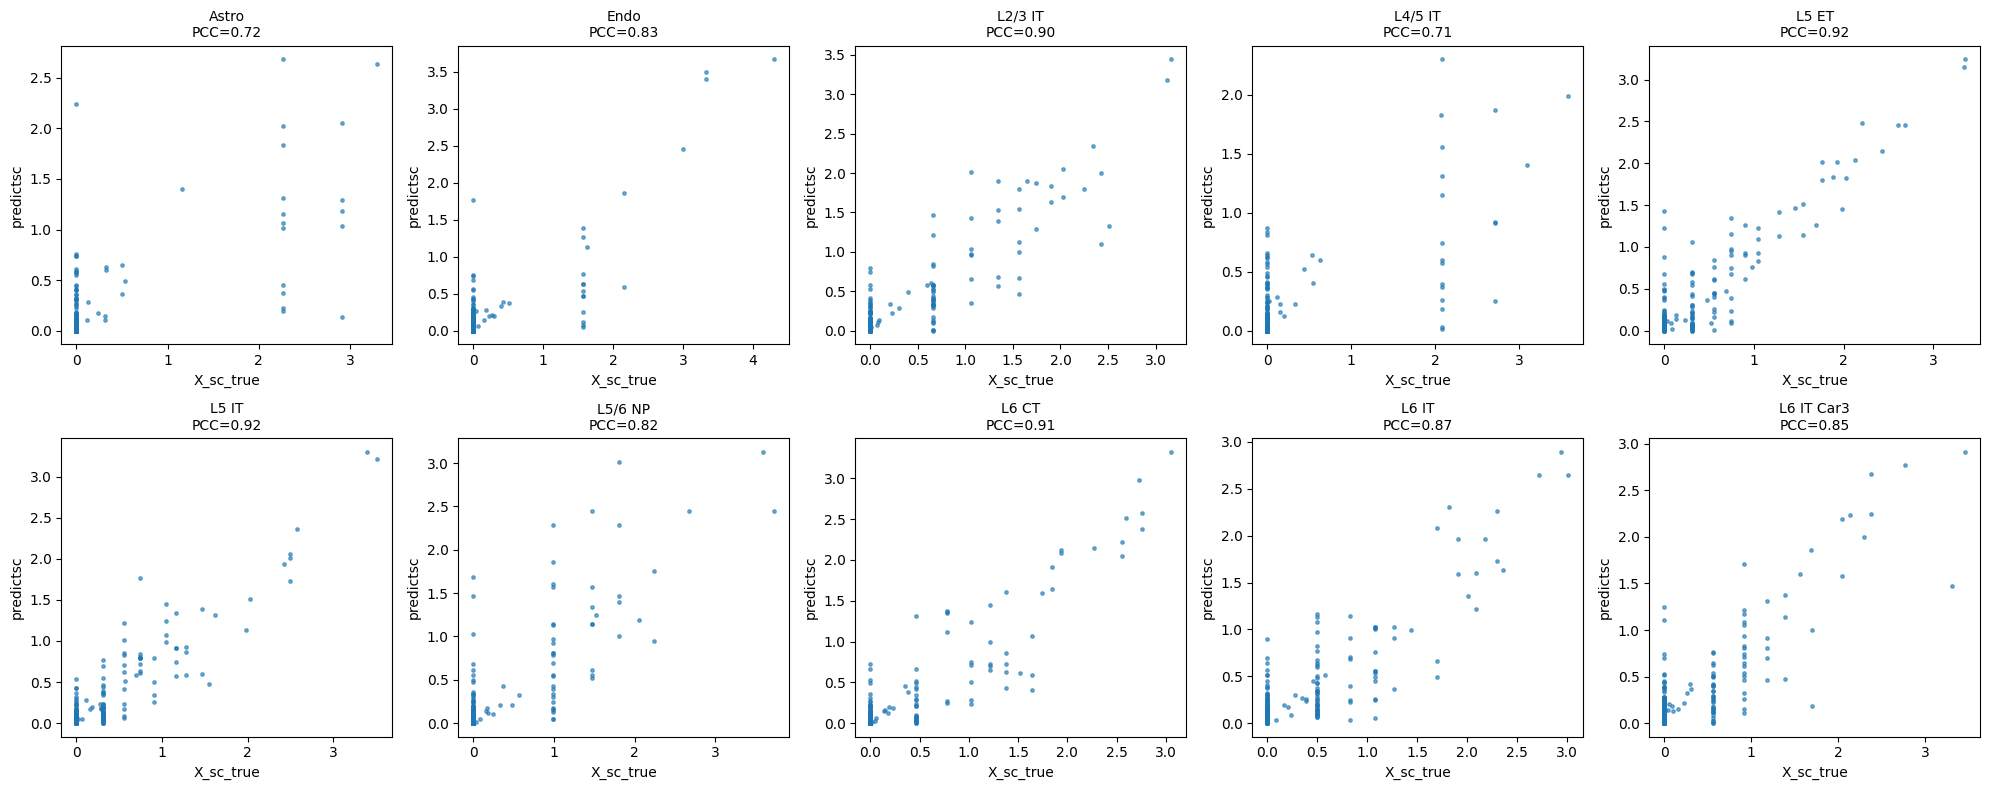

In [119]:
result_ours=evaluate_predictions_numpy(
    predictsc,              # (n_sc_cells, n_genes) or embedding
    scembeding,
    np.log(1+adata_sc.X),              # same shape as predictsc (optional, can be None)
    predictst=None,         # (n_spots, n_genes)
    X_st_true=np.log(1+adata_st.X.toarray()),         # (n_spots, n_genes)
    predictA=None,          # (n_spots, n_sc_cells)
    A_gt=None,              # (n_spots, n_sc_cells) or spot × cell assignment
    cell_type_labels=cell_type_labels,  # list[str], length = n_sc_cells
    A_gt_deconv=None,       # (n_spots, n_types)
    cell_types_gt_order=None
)

In [120]:
import torch
import numpy as np
import scanpy as sc
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# ---------- 1. 准备数据 ----------
# 假设 z_cell 是 torch.Tensor，形状 (19979, 32)
# 假设 cell_type_labels 是 numpy array 或 list，长度 19979

# 将 tensor 转为 numpy (如果是 GPU 需要先 .cpu())
z_np = z_cell.cpu().numpy() if z_cell.is_cuda else z_cell.numpy()
#z_np =  np.load('/home/qyyuan/project/ST_CP/JE/method/fix_enc_pca1_top5000_kl_soft_harm_z_cell-simulationdata-BestModel0.npy')
# 真实标签 (确保是字符串或整数)
true_labels = adata_sc.obs['celltype'].values

print(f"嵌入形状: {z_np.shape}")
print(f"标签数量: {len(true_labels)}")
print(f"真实细胞类型数: {len(np.unique(true_labels))}")

# ---------- 2. 创建临时 AnnDataA 对象 ----------
adata = sc.AnnData(z_np)
adata.obs['celltype'] = true_labels  # 存入真实标签以便后续对比

# ---------- 3. 构建 KNN 图并运行 Louvain ----------
# 设置邻居数 (根据数据量，15-30 都是合理的)
n_neighbors = 20

# 计算邻居图 (在 32 维嵌入上)
sc.pp.neighbors(adata, n_neighbors=n_neighbors, use_rep='X')

# 尝试多个分辨率，找到最佳聚类结果
resolutions = [0.2, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0]

results = []
best_nmi = -1
best_ari = -1
best_res = None

for res in resolutions:
    # 运行 Louvain
    sc.tl.louvain(adata, resolution=res, key_added=f'louvain_r{res}')
    pred_labels = adata.obs[f'louvain_r{res}'].values
    
    # 计算指标
    ari = adjusted_rand_score(true_labels, pred_labels)
    nmi = normalized_mutual_info_score(true_labels, pred_labels)
    
    results.append({'resolution': res, 'ARI': ari, 'NMI': nmi})
    
    if nmi > best_nmi:
        best_nmi = nmi
        best_ari = ari
        best_res = res
    
    print(f"Resolution {res:.1f} -> ARI: {ari:.4f}, NMI: {nmi:.4f}")

# ---------- 4. 输出最佳结果 ----------
print("\n" + "="*50)
print(f"最佳分辨率: {best_res}")
print(f"最佳 NMI: {best_nmi:.4f}")
print(f"对应 ARI: {best_ari:.4f}")
print("="*50)

# ---------- 5. (可选) 如果只想用默认分辨率跑一次 ----------
# 也可以直接使用默认分辨率 1.0
# sc.tl.louvain(adata, resolution=1.0)
# pred_labels = adata.obs['louvain'].values
# ari = adjusted_rand_score(true_labels, pred_labels)
# nmi = normalized_mutual_info_score(true_labels, pred_labels)
# print(f"Default (res=1.0) -> ARI: {ari:.4f}, NMI: {nmi:.4f}")

嵌入形状: (4198, 32)
标签数量: 4198
真实细胞类型数: 23
Resolution 0.2 -> ARI: 0.6400, NMI: 0.7927
Resolution 0.5 -> ARI: 0.6947, NMI: 0.8109
Resolution 0.8 -> ARI: 0.5901, NMI: 0.7894
Resolution 1.0 -> ARI: 0.5915, NMI: 0.7904
Resolution 1.2 -> ARI: 0.6205, NMI: 0.8026
Resolution 1.5 -> ARI: 0.6286, NMI: 0.8085
Resolution 2.0 -> ARI: 0.5672, NMI: 0.7911

最佳分辨率: 0.5
最佳 NMI: 0.8109
对应 ARI: 0.6947


In [122]:
pd.DataFrame(scembeding).to_csv('ours/merfish_sc_embeding.csv')

In [123]:
pd.DataFrame(predictsc).to_csv('ours/merfish_sc_pred_0425.csv')

In [124]:
pd.DataFrame(np.log(1+adata_sc.X)).to_csv('ours/merfish_sc_groundtruth_0425.csv')

In [121]:
result_ours


({'predictsc_row_pcc': 0.8427142459702185,
  'predictsc_col_pcc': 0.7437532873838906,
  'silhouette_index': 0.41670154614403293},
 None)

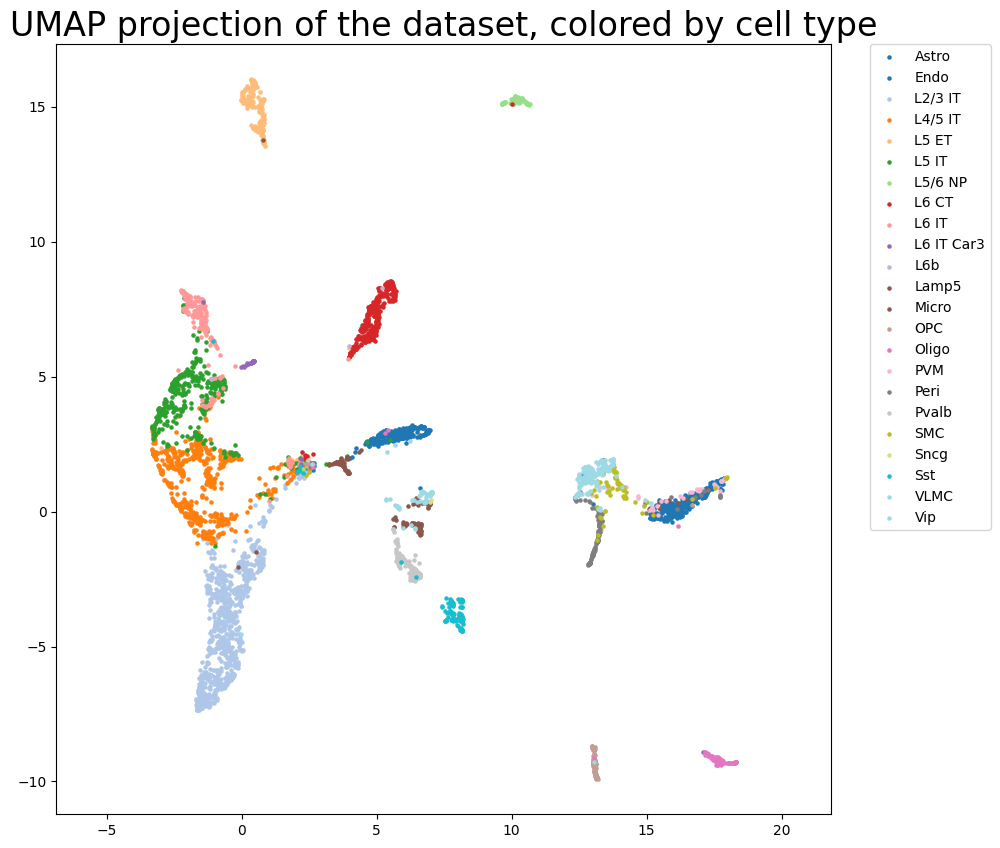

In [30]:
import umap
import matplotlib.pyplot as plt
import numpy as np

# 假设 scembedding 是你的单细胞嵌入数据，形状为 (n_cells, n_features)
# cell_type_labels 是一个包含每个细胞类型的标签列表或数组，长度为 n_cells
# 示例数据
# scembedding = ...  # 你的单细胞嵌入数据
# cell_type_labels = ...  # 你的细胞类型标签
# 使用UMAP降维
reducer = umap.UMAP()
embedding = reducer.fit_transform(scembeding)
# 获取所有独特的细胞类型用于配色
unique_cell_types = np.unique(cell_type_labels)
# 为每种细胞类型生成颜色
colors = plt.cm.get_cmap('tab20', len(unique_cell_types))
plt.figure(figsize=(10, 10))
# 绘制每个细胞类型
for i, cell_type in enumerate(unique_cell_types):
    mask = cell_type_labels == cell_type
    plt.scatter(embedding[mask, 0], embedding[mask, 1], c=[colors(i)], label=cell_type, s=5)

plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of the dataset, colored by cell type', fontsize=24)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

## fix the encoder result and optimize A

In [305]:
adata_sc = sc.read("/home/qyyuan/project/ST_CP/JE/simulation/MERFISH/adata_sc_mouse1sample1_mouse1_slice50_celltype.h5ad")
common_genes=adata_sc.var_names
device='cuda:2'
predictsc = np.load('/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/ours/predictsc.npy')
scembeding = np.load('/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/ours/scembeding.npy')
sc_path = "/home/qyyuan/project/ST_CP/JE/simulation/MERFISH/adata_sc_mouse1sample1_mouse1_slice50_celltype.h5ad"
st_path = "/home/qyyuan/project/ST_CP/JE/simulation/MERFISH/adata_st_mouse1sample1_mouse1_slice50_drop.h5ad"
sc_data_path = sc_path
st_data_path = st_path
count_file_path='/home/qyyuan/project/ST_CP/JE/simulation/MERFISH/spots_info.csv'
checkpoint_path =  '/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/ours/no_pca_pred_zcell.pth'
checkpoint = torch.load(checkpoint_path, map_location='cuda:2', weights_only=False)
#common_genes=checkpoint['common_genes']
Count_cell=pd.read_csv(count_file_path)
num_cell=Count_cell['n_cells'].values
num_cell = torch.tensor(num_cell, device='cuda:2')

import os
import torch
import numpy as np66

print("=" * 60)
print("Starting improved model training")
print("=" * 60)
# Train model
model, common_genes, losses = train_vae_poisson_model(
    sc_path=sc_data_path,
    st_path=st_data_path,
    num_cell=num_cell,
    output_dir='SpatialVG_improved_NMF', common_genes=common_genes,
    embedding_dim=32, 
    lr=0.05, 
    epochs=200, 
    lambda_reg=0.1,lambda_l2=0.01,lambda_l4=0,lambda_l5=0.0000000,lambda_ot=0, lambda_M=1,lambda_M1=1,lambda_r=0.0000,lambda_kl=0.000,lambda_pca=0,lambda_f=0,lambda_row_sum=10,
    n_top_genes=5000 ,
    z_pca=None, predictA=True, f_vals=torch.tensor(predictsc, device='cuda:2'),
    z_cell=torch.tensor(scembeding, device='cuda:2'),
    fix_genes=True,mapping_original='original'
)
# Save results
os.makedirs('SpatialVG_improved_NMF/models', exist_ok=True)
torch.save({
    'model_state_dict': model.state_dict(),
    'common_genes': common_genes,
    'training_losses': losses,
}, 'SpatialVG_improved_NMF/models/fix_enc_harm_getA2.pth')
print("Training completed and model saved.")

Starting improved model training
the number of common gene are 254
Training on device: cuda:2
Epoch   0: Total=0.94, LM=0.37,LM1=0.56, l_f=0.21, row_sum_loss=2.03,l3=0.03
Epoch  20: Total=0.79, LM=0.29,LM1=0.50, l_f=0.21, row_sum_loss=0.58,l3=0.03
Epoch  40: Total=0.69, LM=0.22,LM1=0.46, l_f=0.21, row_sum_loss=0.60,l3=0.03
Epoch  60: Total=0.63, LM=0.18,LM1=0.45, l_f=0.21, row_sum_loss=0.67,l3=0.03
Epoch  80: Total=0.60, LM=0.15,LM1=0.45, l_f=0.21, row_sum_loss=0.71,l3=0.03
Epoch 100: Total=0.58, LM=0.14,LM1=0.44, l_f=0.21, row_sum_loss=0.75,l3=0.03
Epoch 120: Total=0.57, LM=0.13,LM1=0.44, l_f=0.21, row_sum_loss=0.77,l3=0.03
Epoch 140: Total=0.57, LM=0.13,LM1=0.44, l_f=0.21, row_sum_loss=0.79,l3=0.03
Epoch 160: Total=0.56, LM=0.12,LM1=0.43, l_f=0.21, row_sum_loss=0.80,l3=0.03
Epoch 180: Total=0.56, LM=0.12,LM1=0.43, l_f=0.21, row_sum_loss=0.80,l3=0.03
Training completed and model saved.


In [306]:
A_gt_deconv=pd.read_csv('/home/qyyuan/project/ST_CP/JE/simulation/MERFISH/A_gt_simulationdata.csv',sep=',',header=0,index_col=0)
metadata = adata_sc.obs
cell_type_labels =metadata['celltype'].values

In [307]:
sc_path = "/home/qyyuan/project/ST_CP/JE/simulation/MERFISH/adata_sc_mouse1sample1_mouse1_slice50_celltype.h5ad"
st_path = "/home/qyyuan/project/ST_CP/JE/simulation/MERFISH/adata_st_mouse1sample1_mouse1_slice50_drop.h5ad"
# 1. 定义设备
n_top_genes=5000
X_sc, X_st, Y, adata_sc, adata_ST, common_genes = load_and_align_data(sc_path, st_path, n_top_genes,common_genes=common_genes,fix_genes=True)
X_sc = np.log(X_sc + 1)
X_st = np.log(X_st + 1)
adata_st=adata_ST

the number of common gene are 254


In [308]:
model.eval()
device = next(model.parameters()).device
import torch
X_sc_tensor = X_sc.to(device).float()
with torch.no_grad():
    sigmoid_f = torch.sigmoid(model.f).squeeze()
    A_hat = model.compute_softmax_A()
A_hat_np = A_hat.cpu().numpy()
stembeding = A_hat_np @ scembeding
scale = torch.exp(model.log_scale)
predictst = scale.cpu().detach().numpy()*A_hat_np @ (np.exp(predictsc)-1)
#X_st_pred = torch.mm(scale * A_hat, f_vals)
#predictst1 = A_hat_np @ adata_sc.X
A_hat_np=pd.DataFrame(A_hat_np,index=adata_st.obs_names,columns=adata_sc.obs_names)
A_hat_np.index = A_hat_np.index.astype(int)
A_hat_np = A_hat_np.loc[A_gt_deconv.index, :]
cell_types_gt_order=A_gt_deconv.columns.tolist()

In [238]:
pd.DataFrame(stembeding).to_csv('merfish_stembeding.csv')

In [303]:
A_gt=np.load('/home/qyyuan/project/ST_CP/JE/simulation/MERFISH/groundtruth_A_m1s1s50.npy')

In [ ]:
A_gt==A_hat_np.values  

✅ Evaluation complete.


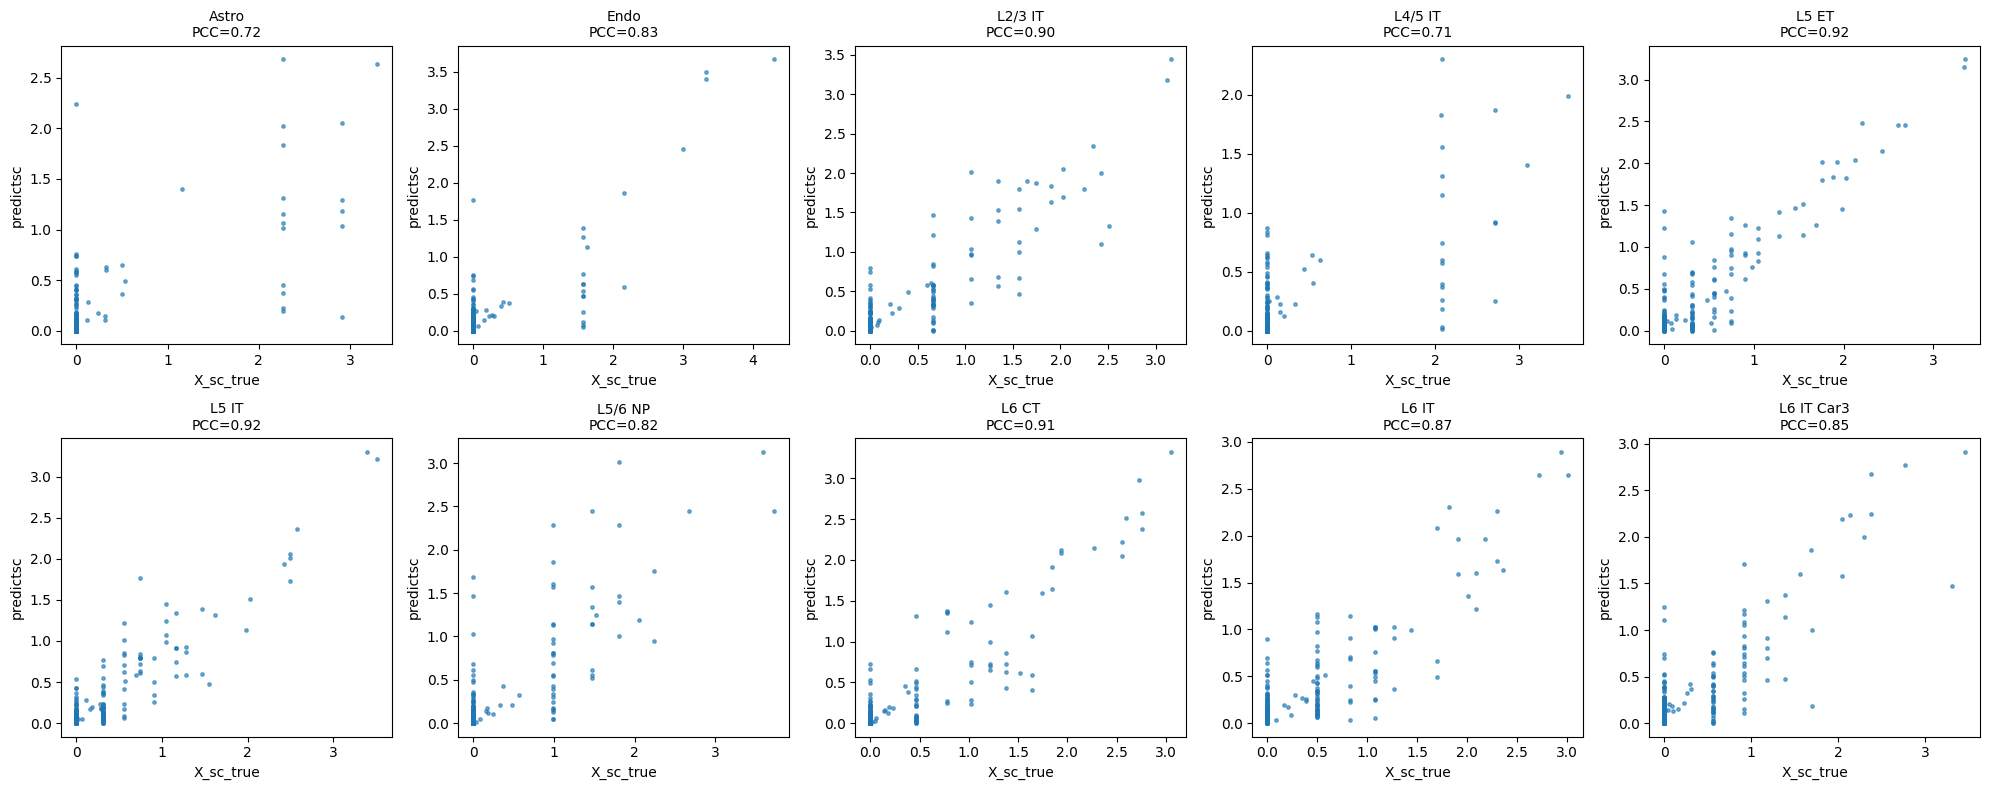

In [309]:
result_ours=evaluate_predictions_numpy(
    predictsc,              # (n_sc_cells, n_genes) or embedding
    None,
    np.log(1+adata_sc.X),              # same shape as predictsc (optional, can be None)
    predictst=np.log(1+predictst),         # (n_spots, n_genes)
    X_st_true=np.log(1+adata_st.X),         # (n_spots, n_genes)
    predictA=A_hat_np.values,          # (n_spots, n_sc_cells)
    A_gt=A_gt,              # (n_spots, n_sc_cells) or spot × cell assignment
    cell_type_labels=cell_type_labels,  # list[str], length = n_sc_cells
    A_gt_deconv=A_gt_deconv,       # (n_spots, n_types)
    cell_types_gt_order=cell_types_gt_order
)

In [310]:
result_ours

({'predictsc_row_pcc': 0.8427142459702185,
  'predictsc_col_pcc': 0.7437532873838906,
  'predictst_row_pcc': 0.35830315584668293,
  'predictst_col_pcc': 0.33680379205918687,
  'assignment_accuracy': 0.01179245283018868,
  'deconv_mean_pcc': 0.6630439299526495,
  'deconv_mean_mae': 0.04213538675451477,
  'deconv_mean_rmse': 0.09315990999774064,
  'PCC_all': [-0.04875148524715224,
   0.7676906626677442,
   0.9951277262018621,
   -0.04955552698959005,
   0.8248966594166076,
   0.7743569513759525,
   0.284062269024648,
   0.9194848761353833,
   0.6473693048112635,
   0.055769831484595474,
   0.6381955126053068,
   0.8781940841649959,
   0.41439891274157,
   0.3898639674079747,
   0.9911109851745129,
   0.6193775097265691,
   0.7759181084745769,
   0.8049052356349689,
   0.8941318857239268,
   0.7890978911232496,
   0.053688644608555915,
   0.8228705521388052,
   0.7027428185799968,
   0.8800002581670424,
   0.059785209261643504,
   0.5382269629070588,
   0.9084248777684296,
   0.3494535634

In [312]:
A_hat_np.to_csv('predicted_A_matrix-0425.csv')

In [ ]:
pd.DataFrame(result_ours[0]['PCC_all'],index=A_gt_deconv.index).to_csv('/pcc_list_0.5-best_by_2026-04-07-version2-simulationdata.csv')

In [313]:
import numpy as np

def get_entropy_uniformity(matrix):
    # 防止 log(0) 报错，加上极小值
    epsilon = 1e-12
    matrix = np.clip(matrix, epsilon, 1)
    
    N = matrix.shape[0] # 行数
    # 计算每列的熵
    entropy = -np.sum(matrix * np.log(matrix), axis=0)
    # 归一化 (除以最大熵 log(N))
    max_entropy = np.log(N)
    uniformity_score = entropy / max_entropy
    
    return uniformity_score

In [341]:
#A_hat_np_n=A_hat_np/A_hat_np.mean(axis=0)
A_hat_np=A_hat_np/A_hat_np.sum(axis=0)
AA=get_entropy_uniformity(A_hat_np)
index0=np.where(AA<0.8)[0]
A_hat_np1 = A_hat_np.iloc[:,index0]


In [342]:
len(index0)

4198

In [343]:
result_ours,A_dec_pred=evaluate_predictions_numpy(
None,              # (n_sc_cells, n_genes) or embedding
None,
np.log(1+adata_sc.X),              # same shape as predictsc (optional, can be None)
predictst=None,         # (n_spots, n_genes)
X_st_true=np.log(1+adata_st.X),         # (n_spots, n_genes)
predictA=A_hat_np1,          # (n_spots, n_sc_cells)
A_gt=None,              # (n_spots, n_sc_cells) or spot × cell assignment
cell_type_labels=cell_type_labels[index0],  # list[str], length = n_sc_cells
A_gt_deconv=A_gt_deconv,       # (n_spots, n_types)
cell_types_gt_order=cell_types_gt_order
)

✅ Evaluation complete.


In [344]:
result_ours

{'deconv_mean_pcc': 0.6630439257536275,
 'deconv_mean_mae': 0.04213538684407317,
 'deconv_mean_rmse': 0.09315991016920765,
 'PCC_all': [-0.0487514925957938,
  0.7676906602859148,
  0.9951277253004926,
  -0.04955552449440745,
  0.8248967471592471,
  0.7743569658754306,
  0.28406233039598655,
  0.9194848862529702,
  0.6473692473192483,
  0.055769813592809796,
  0.6381953750034148,
  0.8781941021791372,
  0.41439900781854905,
  0.3898639139490953,
  0.9911109764448596,
  0.6193775193952976,
  0.7759181012067514,
  0.8049053600940103,
  0.8941318759215933,
  0.7890978578728503,
  0.05368866605554885,
  0.8228704915088182,
  0.7027428422035306,
  0.8800002144953214,
  0.059785169290240386,
  0.5382269182866082,
  0.9084250128804154,
  0.349453545120681,
  0.8181670948510298,
  0.7938305777577709,
  0.8497914021957925,
  0.3892327370239145,
  0.6964082173611403,
  0.9604111528333769,
  0.8243357078509953,
  0.5051109907040991,
  0.7819699311306167,
  0.307296800260873,
  0.38321723703567506,

In [345]:
A_dec_pred1=A_dec_pred.copy()
A_dec_pred1=A_dec_pred1.T/A_dec_pred1.sum(axis=1)
A_dec_pred1=A_dec_pred1.T
AA=get_entropy_uniformity(A_dec_pred1.T)

In [346]:
index1=np.where(AA<0.9)[0]
len(index1)

424

temp

In [347]:
pcc_list = []
for i in range(A_gt_deconv.iloc[index1,:].shape[0]):
    gt_i = A_gt_deconv.iloc[index1,:].values[i]
    pred_i = A_dec_pred1[index1,:][i]
    if np.std(gt_i) < 1e-8 or np.std(pred_i) < 1e-8:
        r = 0.0
        print(1)
    else:
        r, _ = pearsonr(gt_i, pred_i)
        r = float(r) if np.isfinite(r) else 0.0
    pcc_list.append(r)
float(np.mean(pcc_list))

0.6630439256353453

In [348]:
import torch
import numpy as np

def generate_optimized_A_softmax_normalized(A0, adj_matrix, lambda_reg=10.0, lr=0.05, epochs=1000):
    """
    使用归一化拉普拉斯矩阵的版本
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # 1. 数据准备
    A0_tensor = torch.tensor(A0, dtype=torch.float32).to(device)
    W = torch.tensor(adj_matrix, dtype=torch.float32).to(device)
    
    # 2. 构建【归一化】拉普拉斯矩阵 (Symmetric Normalized Laplacian)
    # L_sym = I - D^(-1/2) * W * D^(-1/2)
    
    # 计算度矩阵 D (每一行的和)
    D_vec = torch.sum(W, dim=1)
    
    # 计算 D^(-1/2)
    # 加上 eps 防止除以 0 (如果有孤立点)
    eps = 1e-8
    D_inv_sqrt = torch.diag(1.0 / torch.sqrt(D_vec + eps))
    
    # 计算 L_sym
    # I 是单位矩阵
    I = torch.eye(W.shape[0]).to(device)
    L_sym = I - torch.mm(torch.mm(D_inv_sqrt, W), D_inv_sqrt)
    
    # 3. 初始化 S (Logits)
    eps_log = 1e-8
    S_init = torch.log(A0_tensor )
    S = torch.nn.Parameter(S_init + torch.randn_like(S_init) * 0.01)
    
    optimizer = torch.optim.Adam([S], lr=lr)
    
    print(f"开始优化 (使用归一化拉普拉斯, Device: {device})...")
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        
        # --- 核心：通过 Softmax 得到 A ---
        A = torch.softmax(S, dim=1)
        
        # --- 目标 1: 余弦相似度 ---
        norm_A = torch.norm(A, dim=1, keepdim=True)
        norm_A0 = torch.norm(A0_tensor, dim=1, keepdim=True)
        norm_A = torch.clamp(norm_A, min=1e-8)
        norm_A0 = torch.clamp(norm_A0, min=1e-8)
        
        dot_product = torch.sum(A * A0_tensor, dim=1, keepdim=True)
        cos_sim = dot_product / (norm_A * norm_A0)
        loss_sim = torch.mean(1 - cos_sim)
        
        # --- 目标 2: 图平滑性 (使用 L_sym) ---
        # Tr(A^T * L_sym * A)
        # 注意：这里直接用矩阵乘法链式计算
        loss_smooth = torch.trace(torch.mm(torch.mm(A.t(), L_sym), A))
        
        # --- 总损失 ---
        loss = loss_sim + lambda_reg * loss_smooth
        
        loss.backward()
        optimizer.step()
        
        # 监控
        if (epoch + 1) % 200 == 0:
            print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}, "
                  f"Sim: {loss_sim.item():.4f}, Smooth: {loss_smooth.item():.4f}")
            
    A_final = torch.softmax(S, dim=1)
    return A_final.detach().cpu().numpy()

# ==========================================
# 使用示例
# ==========================================
# 注意：lambda_reg 可能需要调大，因为归一化后 Smooth Loss 数值会变小
# A_result = generate_optimized_A_softmax_normalized(A0_prob, adj_data, lambda_reg=50.0)

In [349]:
Count_cell=adata_st.obsm['spatial']

In [350]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

# 1. 模拟数据：假设 coords 是你的 (3000, 2) 坐标矩阵
# np.random.seed(42)
# coords = np.random.rand(3000, 2) * 100  # 替换为你真实的 x, y 数据
coords=Count_cell
# 2. 构建 KNN 模型
# n_neighbors=10 表示找最近的10个点 (包含自身)
# metric='euclidean' 表示使用欧几里得距离
knn = NearestNeighbors(n_neighbors=3, metric='euclidean')
knn.fit(coords)
# 3. 获取邻接关系
# kneighbors 返回两个矩阵：(距离, 索引)
distances, indices = knn.kneighbors(coords)

# 4. 生成邻接矩阵 (Adjacency Matrix)
# 初始化一个全 0 矩阵
adj_matrix = np.zeros((coords.shape[0], coords.shape[0]))

# 填充矩阵
# 对于每一行 i，将 indices[i] 对应的位置设为 1 (或者设为具体的距离值)
for i in range(coords.shape[0]):
    adj_matrix[i, indices[i]] = 1 
    # 如果你想用距离作为权重，可以使用: adj_matrix[i, indices[i]] = 1 / (distances[i] + 1e-5)

# 5. (可选) 对称化
# 如果 A 是 B 的邻居，通常也让 B 是 A 的邻居 (无向图)
adj_matrix = np.maximum(adj_matrix, adj_matrix.T)

print("邻接矩阵形状:", adj_matrix.shape)
print("非零元素数量:", np.count_nonzero(adj_matrix))

邻接矩阵形状: (424, 424)
非零元素数量: 1498


In [351]:
# ==========================================
# 模拟数据与运行示例
# ==========================================

A0_data = A_dec_pred1.copy()

# 2. 模拟 距离矩阵/KNN网络 (3000 x 3000)
# 这里为了演示，随机生成一个稀疏的邻接矩阵
# 实际使用时，请用你的 KNN 结果替换这里

adj_data = adj_matrix.copy()

# 3. 运行优化
# lambda_reg 越大，相邻的行使向量越相似；越小，越贴近 A0
A_optimized = generate_optimized_A_softmax_normalized(A0_data, adj_data, lambda_reg=0.01,epochs=5000)

print("优化完成，A 的形状:", A_optimized.shape)

开始优化 (使用归一化拉普拉斯, Device: cuda)...
Epoch 200, Loss: 0.1047, Sim: 0.0516, Smooth: 5.3123
Epoch 400, Loss: 0.1046, Sim: 0.0515, Smooth: 5.3050
Epoch 600, Loss: 0.1046, Sim: 0.0515, Smooth: 5.3046
Epoch 800, Loss: 0.1046, Sim: 0.0515, Smooth: 5.3046
Epoch 1000, Loss: 0.1046, Sim: 0.0515, Smooth: 5.3045
Epoch 1200, Loss: 0.1046, Sim: 0.0515, Smooth: 5.3045
Epoch 1400, Loss: 0.1046, Sim: 0.0515, Smooth: 5.3045
Epoch 1600, Loss: 0.1046, Sim: 0.0515, Smooth: 5.3045
Epoch 1800, Loss: 0.1046, Sim: 0.0515, Smooth: 5.3046
Epoch 2000, Loss: 0.1046, Sim: 0.0515, Smooth: 5.3048
Epoch 2200, Loss: 0.1046, Sim: 0.0515, Smooth: 5.3046
Epoch 2400, Loss: 0.1046, Sim: 0.0515, Smooth: 5.3045
Epoch 2600, Loss: 0.1046, Sim: 0.0515, Smooth: 5.3045
Epoch 2800, Loss: 0.1046, Sim: 0.0515, Smooth: 5.3044
Epoch 3000, Loss: 0.1046, Sim: 0.0515, Smooth: 5.3047
Epoch 3200, Loss: 0.1046, Sim: 0.0515, Smooth: 5.3047
Epoch 3400, Loss: 0.1046, Sim: 0.0515, Smooth: 5.3046
Epoch 3600, Loss: 0.1046, Sim: 0.0515, Smooth: 5.304

In [352]:
pcc_list = []
for i in range(A_gt_deconv.iloc[:,:].shape[0]):
    gt_i = A_gt_deconv.iloc[:,:].values[i]
    pred_i = A_optimized[:,:][i]
    if np.std(gt_i) < 1e-8 or np.std(pred_i) < 1e-8:
        r = 0.0
        print(1)
    else:
        r, _ = pearsonr(gt_i, pred_i)
        r = float(r) if np.isfinite(r) else 0.0
    pcc_list.append(r)
float(np.mean(pcc_list))

0.6997578794781129

In [353]:
pd.DataFrame(A_optimized,columns=cell_types_gt_order).to_csv('merfish_A_optimized_0425.csv')

In [354]:

pd.DataFrame(A_dec_pred1,columns=cell_types_gt_order).to_csv('merfish_A_pred_0425.csv')

In [356]:
pd.DataFrame(pcc_list,index=A_gt_deconv.index).to_csv('pcc_list_final')

In [359]:
#function
# function
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import mean_squared_error

def evaluate_deconvolution(pred, true, eps=1e-12):
    """
    评估空间去卷积预测结果与真实值的多种指标。
    
    参数：
        pred : np.ndarray, shape (n_spots, n_celltypes)
            预测的细胞类型比例矩阵。
        true : np.ndarray, shape (n_spots, n_celltypes)
            真实的细胞类型比例矩阵。
        eps : float
            用于避免对数值零的微小常数。
    
    返回：
        pd.DataFrame : 包含所有评估指标的 DataFrame，索引为指标名称。
    """
    # 确保输入为 numpy 数组
    pred = np.asarray(pred)
    true = np.asarray(true)
    assert pred.shape == true.shape, "预测矩阵和真实矩阵形状不一致"
    n_spots, n_types = pred.shape
    
    # 为避免因全零行导致的相关系数计算问题，过滤掉所有值均为常数的行/列
    # 但为简单起见，我们直接计算并处理 nan
    
    # ---- 1. 按 spot 计算 PCC 和 Spearman ----
    spot_pcc = []
    spot_spearman = []
    for i in range(n_spots):
        p = pred[i, :]
        t = true[i, :]
        # 跳过所有值相同的行（无法计算相关系数）
        if np.std(p) > eps and np.std(t) > eps:
            pcc, _ = pearsonr(p, t)
            spearman, _ = spearmanr(p, t)
            spot_pcc.append(pcc)
            spot_spearman.append(spearman)
        # 否则跳过（不计入平均）
    mean_spot_pcc = np.nanmean(spot_pcc) if spot_pcc else np.nan
    mean_spot_spearman = np.nanmean(spot_spearman) if spot_spearman else np.nan
    
    # ---- 2. 按 cell type 计算 PCC 和 Spearman ----
    type_pcc = []
    type_spearman = []
    for j in range(n_types):
        p = pred[:, j]
        t = true[:, j]
        if np.std(p) > eps and np.std(t) > eps:
            pcc, _ = pearsonr(p, t)
            spearman, _ = spearmanr(p, t)
            type_pcc.append(pcc)
            type_spearman.append(spearman)
    mean_type_pcc = np.nanmean(type_pcc) if type_pcc else np.nan
    mean_type_spearman = np.nanmean(type_spearman) if type_spearman else np.nan
    
    # ---- 3. 整体 MSE 和 RMSE ----
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    
    # ---- 4. Jensen-Shannon 散度 (按 spot 平均) ----
    # 对每个 spot，归一化预测和真实分布（如果已经为概率则无需，但加保护）
    jsd_list = []
    for i in range(n_spots):
        p = pred[i, :]
        t = true[i, :]
        # 确保非负
        p = np.maximum(p, 0)
        t = np.maximum(t, 0)
        # 归一化为概率分布（和为1）
        p = p / (np.sum(p) + eps)
        t = t / (np.sum(t) + eps)
        # Jensen-Shannon 散度 = (KL(p||m) + KL(t||m)) / 2, m = (p+t)/2
        # scipy 的 jensenshannon 返回 sqrt(JSD)，我们取平方得到 JSD
        jsd = jensenshannon(p, t, base=2) ** 2  # base=2 给出以2为底的对数，结果在[0,1]
        jsd_list.append(jsd)
    mean_jsd = np.mean(jsd_list)
    
    # ---- 组装 DataFrame ----
    results = {
        'metric': [
            'mean_spot_pcc',
            'mean_spot_spearman',
            'mean_type_pcc',
            'mean_type_spearman',
            'overall_mse',
            'overall_rmse',
            'mean_jsd'
        ],
        'value': [
            mean_spot_pcc,
            mean_spot_spearman,
            mean_type_pcc,
            mean_type_spearman,
            mse,
            rmse,
            mean_jsd
        ]
    }
    df = pd.DataFrame(results)
    df.set_index('metric', inplace=True)
    return df



In [112]:
A_gt_deconv=pd.read_csv('/home/qyyuan/project/ST_CP/JE/simulation/MERFISH/A_gt_simulationdata.csv',sep=',',header=0,index_col=0)


In [357]:
A_optimized1=A_optimized.copy()
A_optimized1[A_optimized1<0.045]=0
A_optimized1=A_optimized1/A_optimized1.sum(axis=1,keepdims=True)

In [360]:
df_results_ours = evaluate_deconvolution(A_optimized1, A_gt_deconv.values)


In [ ]:
df_results_ours0 = evaluate_deconvolution(A_optimized, A_gt_deconv.values)


In [361]:
df_results_ours

,value
metric,
mean_spot_pcc,0.690609
mean_spot_spearman,0.534095
mean_type_pcc,0.575177
mean_type_spearman,0.490468
overall_mse,0.008098
overall_rmse,0.089990
mean_jsd,0.325459
